In [1]:
import pandas as pd
import numpy as np

# 1. Chargement (ajuste le nom du fichier si nécessaire)
df = pd.read_csv('data_clean1.csv')

# 2. Conversion forcée en numérique (sécurité anti-"0")
# errors='coerce' transforme les textes bizarres en NaN au lieu de bloquer le code
df['nombre_de_lots_de_stationnement'] = pd.to_numeric(df['nombre_de_lots_de_stationnement'], errors='coerce').fillna(0)
df['nombre_de_lots_a_usage_d_habitation'] = pd.to_numeric(df['nombre_de_lots_a_usage_d_habitation'], errors='coerce')

# 3. Calcul du KPI "Killer"
# On remplace les habitations à 0 par NaN pour éviter la division par zéro (qui fausse la moyenne)
df['taux_tension'] = df['nombre_de_lots_de_stationnement'] / df['nombre_de_lots_a_usage_d_habitation'].replace(0, np.nan)

# 4. Groupement par commune
# On calcule la moyenne du taux et on compte le nombre de copropriétés pour vérifier la fiabilité
analyse_parkshare = df.groupby('commune').agg({
    'taux_tension': 'mean',
    'nombre_de_lots_de_stationnement': 'sum',
    'nombre_de_lots_a_usage_d_habitation': 'sum'
}).reset_index()

# 5. Tri : Les zones les plus en galère de parking en haut (proche de 0)
zones_prioritaires = analyse_parkshare.sort_values(by='taux_tension', ascending=True)

# Affichage du résultat
zones_prioritaires.head()

,commune,taux_tension,nombre_de_lots_de_stationnement,nombre_de_lots_a_usage_d_habitation
32,77024,0.0,0.0,13.0
35,77032,0.0,0.0,4.0
26,77008,0.0,0.0,2.0
45,77050,0.0,0.0,2.0
966,95492,0.0,0.0,2.0


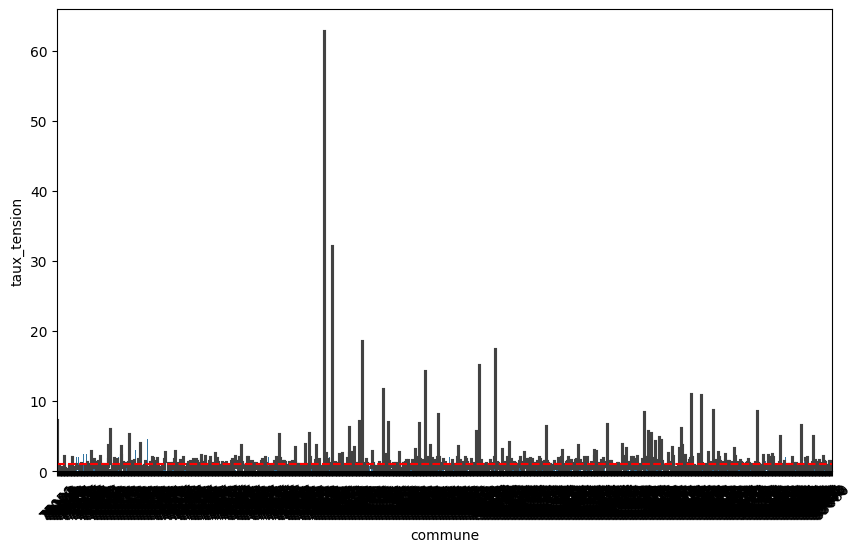

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Graphique de tension par commune
plt.figure(figsize=(10,6))
sns.barplot(x='commune', y='taux_tension', data=df)
plt.axhline(1, color='red', linestyle='--') # Ligne d'alerte
plt.xticks(rotation=45)
plt.show()

In [13]:
df.to_csv("taux_tension.csv", index=False)